/tmp/ipykernel_9719/263755536.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  source["Measurement Time"] = pd.to_datetime(source["Measurement Time"])
/tmp/ipykernel_9719/263755536.py:25: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  source = source.resample("12H").last()


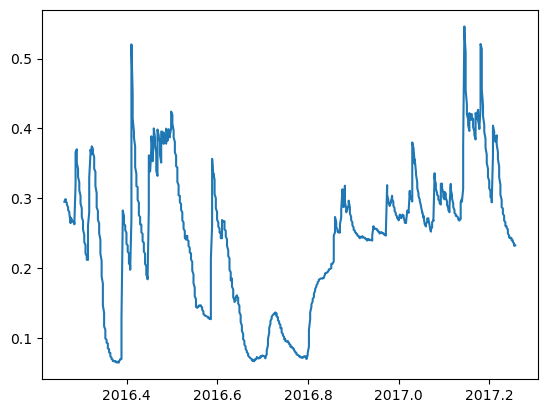

/tmp/ipykernel_9719/263755536.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  source["Measurement Time"] = pd.to_datetime(source["Measurement Time"])
/tmp/ipykernel_9719/263755536.py:25: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  source = source.resample("12H").last()


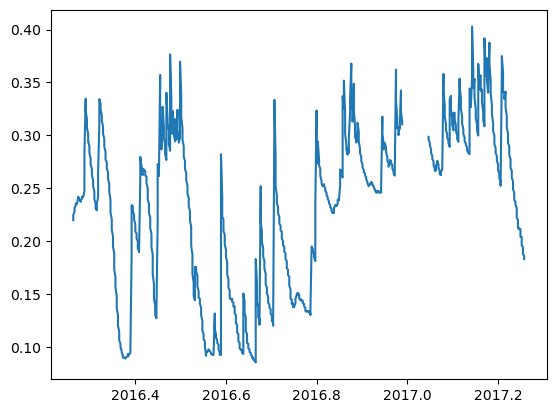

/tmp/ipykernel_9719/263755536.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  source["Measurement Time"] = pd.to_datetime(source["Measurement Time"])
/tmp/ipykernel_9719/263755536.py:25: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  source = source.resample("12H").last()


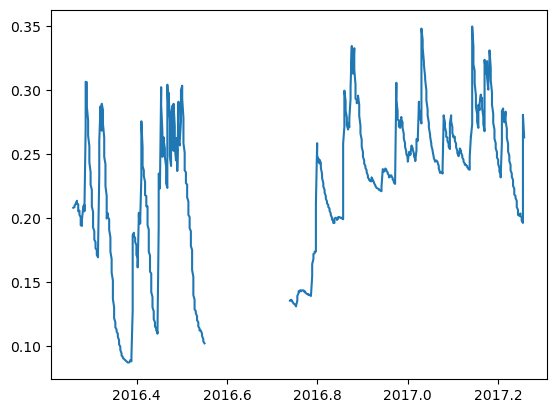

/tmp/ipykernel_9719/263755536.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  source["Measurement Time"] = pd.to_datetime(source["Measurement Time"])
/tmp/ipykernel_9719/263755536.py:25: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  source = source.resample("12H").last()


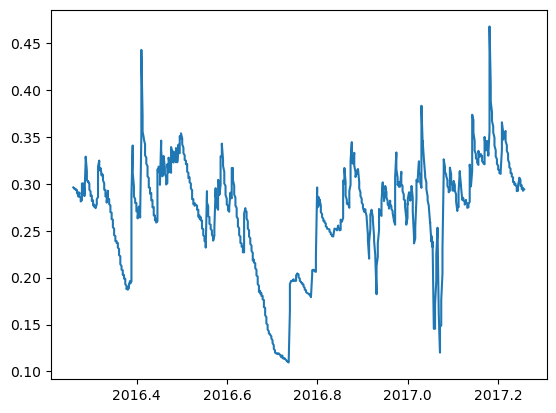

/tmp/ipykernel_9719/263755536.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  source["Measurement Time"] = pd.to_datetime(source["Measurement Time"])
/tmp/ipykernel_9719/263755536.py:25: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  source = source.resample("12H").last()


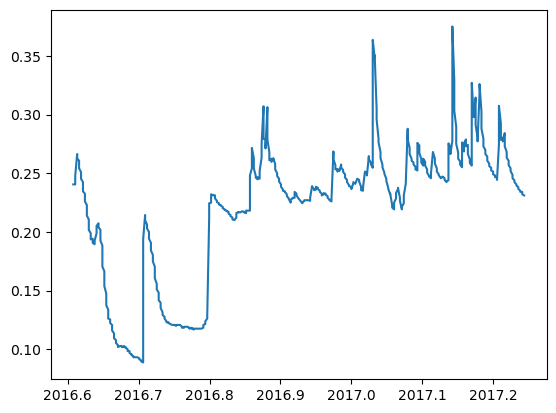

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from pathlib import Path
import os
import sys
from pathlib import Path
home = Path.home()
subdir = home / "src" / "at-gpflow" / "experiments" / "soil-moisture" / "Wageningen" ## or whatever folder at-gpflow lives in
at_dir = home / "src" / "at-gpflow"


sys.path.append(str(at_dir))
sys.path.append(str(subdir))
BASE = str(subdir)

station_indices = ["15", "14", "02", "04", "05"]
substations = []

for station in station_indices:

    source = pd.read_csv(BASE+f"/data/station_data/RM_SM_{station}_calibrated.csv")
    source["Measurement Time"] = pd.to_datetime(source["Measurement Time"])
    source.index = source["Measurement Time"]
    source = source.resample("12H").last()

    source['decimal_year'] = source['Measurement Time'].dt.year + (source['Measurement Time'].dt.dayofyear - 1) / 365.25
    source.index = source["decimal_year"]
    substations.append(source)

    plt.plot(source.index, source["5 cm VWC [m3/m3]"])
    plt.show()


In [2]:
condition_index = 2
data_X = []
data_Y = []

for i, data in enumerate(substations):
    Ax = data.index.to_numpy().reshape(-1, 1)
    Ay_nans = data["5 cm VWC [m3/m3]"].to_numpy().reshape(-1, 1) 
    Ay = Ay_nans[~np.isnan(Ay_nans)].reshape(-1, 1)
    Ay = (Ay - Ay.mean()) / np.std(Ay)
    Ax = Ax[~np.isnan(Ay_nans)].reshape(-1, 1)

    if i == condition_index:
        Xtest, ytest = Ax[int(0.8*len(Ax)):], Ay[int(0.8*len(Ay)):]
        Ax, Ay = Ax[:int(0.8*len(Ax))], Ay[:int(0.8*len(Ay))]
    data_X.append(np.hstack((Ax, i*np.ones_like(Ax))))
    data_Y.append(np.hstack((Ay, i*np.ones_like(Ay))))

X = np.vstack(tuple(data_X))
y = np.vstack(tuple(data_Y))

2026-09-04 17:59:59.856360: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-04 17:59:59.857905: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-04 17:59:59.883973: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-04 17:59:59.885084: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-04 18:00:00.479368: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT

╒════════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤════════════════╕
│ name                                               │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value          │
╞════════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪════════════════╡
│ ConditionalMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0            │
├────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────────┤
│ ConditionalMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0            │
├────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────

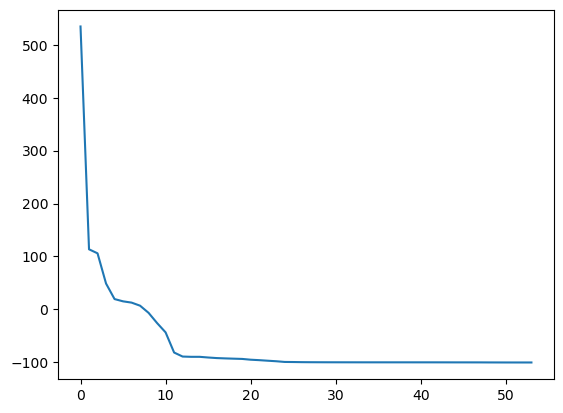

╒════════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤════════════════════════════════════════╕
│ name                                               │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                                  │
╞════════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪════════════════════════════════════════╡
│ ConditionalMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.48456                                │
├────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────────────────────────────────┤
│ ConditionalMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.0169254873393

In [3]:
from atmodel import SparseCMOGP, ConditionalMOGP
from atlikelihood import TransferLikelihood
import gpflow as gpf

def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50})
    plt.plot(res["loss_history"])
    plt.show()

output_dim = len(substations) # Number of outputs
rank = 2  # Rank of W

# Base kernel
k = gpf.kernels.Matern32(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

kern = k * coreg

model1 = ConditionalMOGP((X, y), kernel=kern, conditioning_index=condition_index, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))

gpf.utilities.print_summary(model1)
optimize(model1)
gpf.utilities.print_summary(model1)


/tmp/ipykernel_9719/561439495.py:18: RuntimeWarning: invalid value encountered in sqrt
  (fmean - 2 * np.sqrt(fvar))[:, 0],
/tmp/ipykernel_9719/561439495.py:19: RuntimeWarning: invalid value encountered in sqrt
  (fmean + 2 * np.sqrt(fvar))[:, 0],


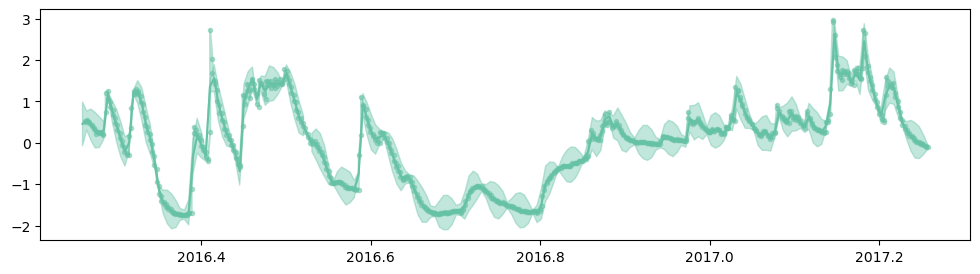

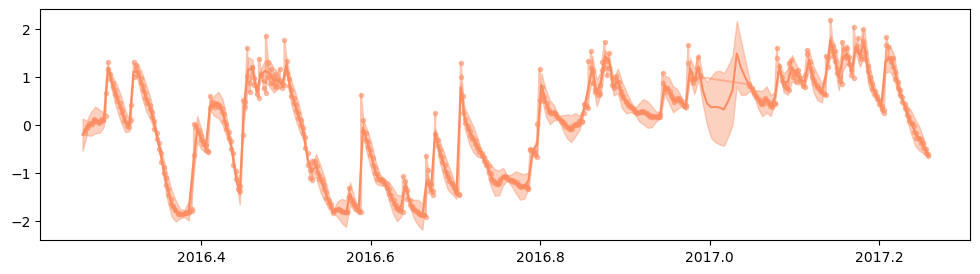

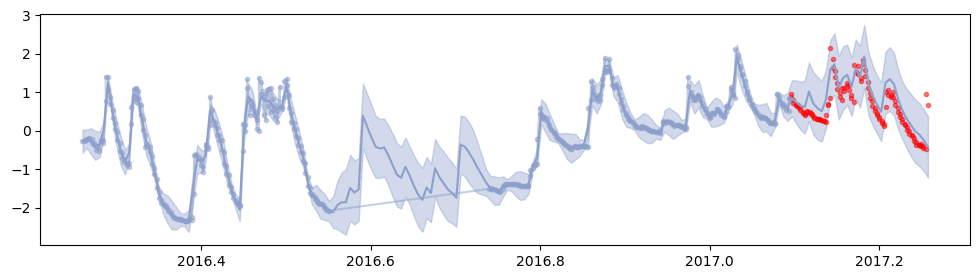

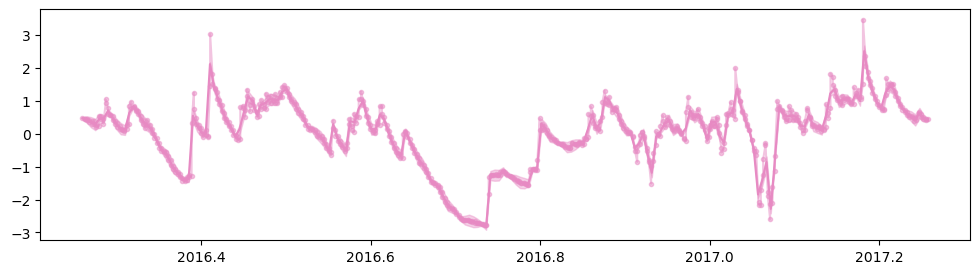

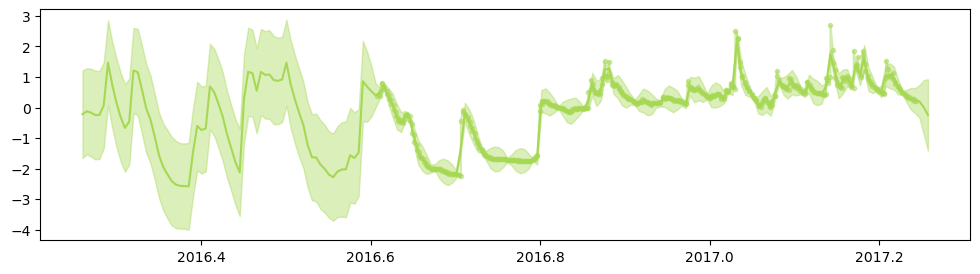

0.11729967296763567

In [4]:
from sklearn.metrics import mean_squared_error
from matplotlib import color_sequences
Xtst = Xtest.reshape(-1, 1)

colors = color_sequences["Set2"]
for index in range(output_dim):
    Ax, Ay = X[X[:,1] == index], y[y[:,1] == index]
    Xplot = np.hstack((np.linspace(min(X[:,0]), max(X[:,0]), 200)[:,None], index*np.ones((200, 1))))
    fmean, fvar = model1.predict_f(Xplot)
    plt.figure(figsize=(12, 3))
    if index == condition_index:  
       fmean_test, fvar_test = model1.predict_f(np.hstack((Xtest, index*np.ones((len(Xtest), 1)))))
       plt.plot(Xtest, ytest, "r.", alpha=0.5)
    plt.plot(Xplot[:,0], fmean, color=colors[index], label="source predictions")
    plt.plot(Ax[:,0], Ay[:,0], color=colors[index], marker=".", alpha=0.5, label="source")
    plt.fill_between(
        Xplot[:, 0],
        (fmean - 2 * np.sqrt(fvar))[:, 0],
        (fmean + 2 * np.sqrt(fvar))[:, 0],
        color=colors[index],
        alpha=0.4,
    )
    plt.show()

ours_mse = mean_squared_error(ytest, fmean_test)
ours_mse

noise with 3: 0.007 - 
noise with 2: 0.095 - 0.033

(250, 2) (3087, 2) (3087, 2)
╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤════════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value          │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪════════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0            │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0            │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼────────

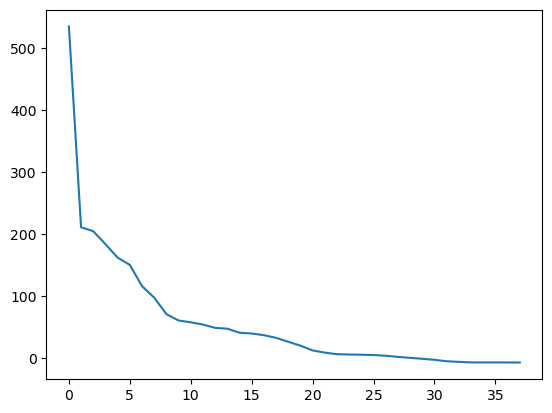

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤════════════════════════════════════════════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                                              │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪════════════════════════════════════════════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 8.24838                                            │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────────────────────────────────────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │

In [38]:
from atmodel import SparseCMOGP, ConditionalMOGP
from atlikelihood import TransferLikelihood
import gpflow as gpf
from robust_svgp import LMCInducingVariable, LMCInducingPointsBase

def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50})
    plt.plot(res["loss_history"])
    plt.show()

output_dim = len(substations) # Number of outputs
rank = 2  # Rank of W

# Base kernel
k = gpf.kernels.Matern32(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)
nIVS = 50 * output_dim
ivs = np.linspace(np.min(X[:,0]), np.max(X[:,0]), nIVS).reshape(-1, 1)
iv_ind = [j * np.ones((int(nIVS/output_dim), 1)) for j in range(output_dim)]
iv_ind = np.concatenate(iv_ind)  # I guess the IPs for the target don't matter here, but this makes the comparison fair.
shuffle = np.random.permutation(np.arange(len(ivs)))
ivs = ivs[shuffle]
ivs = np.hstack((ivs, iv_ind))
print(ivs.shape, X.shape, y.shape)
kern = k * coreg
#m = ConditionalMOGP((X, y), kernel=kern, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
model2 = SparseCMOGP((X, y), conditioning_index=condition_index, exact_target=False, kernel=kern, jitter=1e-5, inducing_variable=LMCInducingPointsBase(ivs), likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
#gpf.set_trainable(m.kernel.kernels[0].variance, True)
#gpf.set_trainable(m.likelihood.source.variance, False)
#print(model2.conditional_likelihood(decompose_likelihood=True))

gpf.utilities.print_summary(model2)
optimize(model2)
gpf.utilities.print_summary(model2)
print(model2.inducing_variable.Z)

In [39]:
W = model2.kernel.kernels[1].W.numpy()
print(W@W.T)

[[169.55278075 212.21800598 219.54326998 113.71028    175.48361888]
 [212.21800598 265.61924765 274.78779631 142.32363972 219.64124396]
 [219.54326998 274.78779631 284.27282159 147.23631539 227.22274059]
 [113.71028    142.32363972 147.23631539  76.25960318 117.68778637]
 [175.48361888 219.64124396 227.22274059 117.68778637 181.6219136 ]]


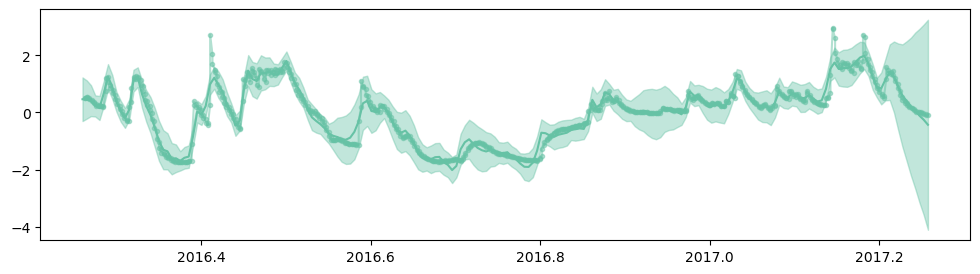

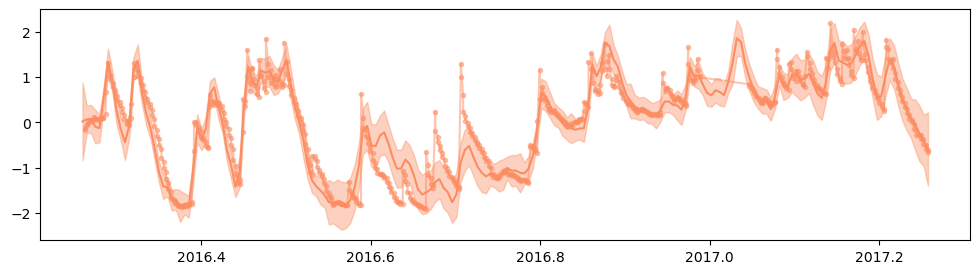

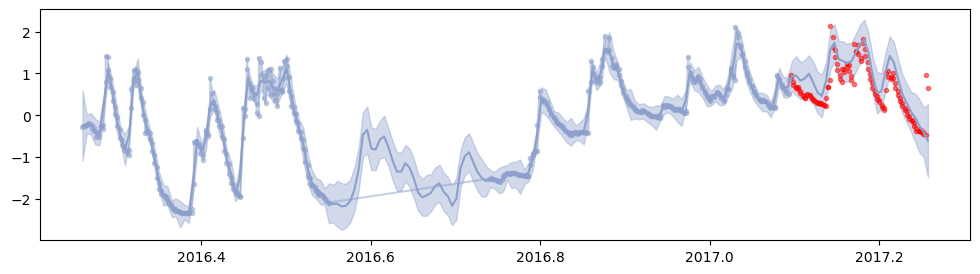

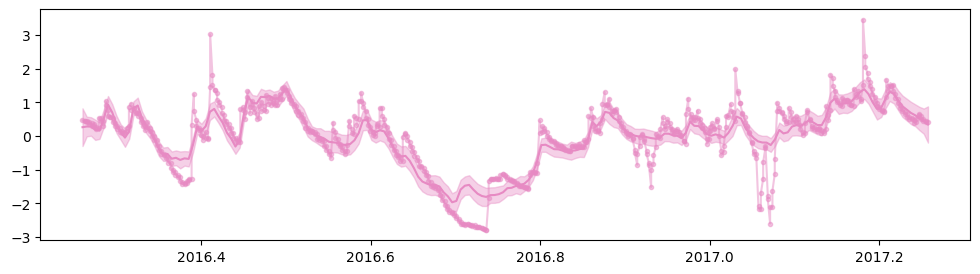

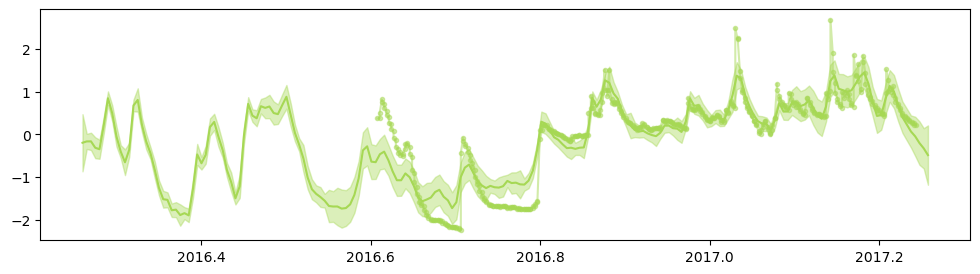

0.13877415699582304

In [40]:
from sklearn.metrics import mean_squared_error
from matplotlib import color_sequences
Xtst = Xtest.reshape(-1, 1)

colors = color_sequences["Set2"]
for index in range(output_dim):
    Ax, Ay = X[X[:,1] == index], y[y[:,1] == index]
    Xplot = np.hstack((np.linspace(min(X[:,0]), max(X[:,0]), 200)[:,None], index*np.ones((200, 1))))
    fmean, fvar = model2.predict_f(Xplot)
    plt.figure(figsize=(12, 3))
    if index == condition_index:  
       fmean_test, fvar_test = model2.predict_f(np.hstack((Xtest, index*np.ones((len(Xtest), 1)))))
       plt.plot(Xtest, ytest, "r.", alpha=0.5)
    plt.plot(Xplot[:,0], fmean, color=colors[index], label="source predictions")
    plt.plot(Ax[:,0], Ay[:,0], color=colors[index], marker=".", alpha=0.5, label="source")
    plt.fill_between(
        Xplot[:, 0],
        (fmean - 2 * np.sqrt(fvar))[:, 0],
        (fmean + 2 * np.sqrt(fvar))[:, 0],
        color=colors[index],
        alpha=0.4,
    )
    plt.show()

ours_mse = mean_squared_error(ytest, fmean_test)
ours_mse